### Note: This notebook contains the initial exploratory analysis, baseline model comparisons, and hyperparameter tuning trials. The final, optimized, and bug-fixed code has been modularized into src/ and training_pipeline/ for production training and deployment.

In [3]:
import tensorflow as tf
import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
DATASET_DIR = r"Solar Panel Defect Classification\data"
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
SEED = 42 # A seed controls randomness

In [4]:
training_data = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    image_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [5]:
validation_data = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    image_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed =  SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [ ]:
classes = training_data.class_names
num_classes = len(classes)

### Some steps for data preparation and speed

In [7]:
# 2. Optimization: Autotune buffer size 
AUTOTUNE = tf.data.AUTOTUNE 

# 3. Apply Normalization (Rescaling 0-255 -> 0-1) 
normalization_layer = keras.layers.Rescaling(1./255) 

def preprocess(image, label): 
  return normalization_layer(image), label 

# 4. Apply optimizations to the pipeline 
train_dataset = training_data.map(preprocess).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_data.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)

## Base Model

In [9]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [10]:
model1 = keras.Sequential([Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))])

# Convolution layer: 1
model1.add(Conv2D(32, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))

# Convolution layer: 2
model1.add(Conv2D(64, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))

# Convolution layer: 3
model1.add(Conv2D(128, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))

model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.5))

model1.add(Dense(num_classes, activation='softmax'))

In [11]:
model1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [20]:
EPOCHS = 10

In [ ]:
# Training the model on 10 epochs

history = model1.fit(
    train_dataset,
    validation_data= validation_dataset,
    epochs = EPOCHS
)

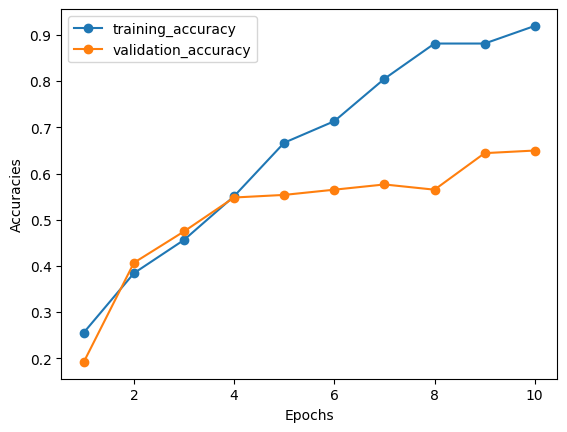

In [23]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1 , EPOCHS +1)

plt.plot(epochs,training_accuracy,label = "training_accuracy",marker = "o")
plt.plot(epochs,validation_accuracy,label = "validation_accuracy",marker = "o")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()

In [ ]:
EPOCHS = 20

history = model1.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

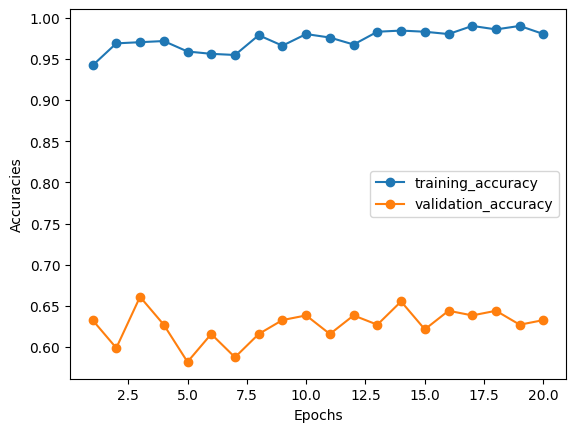

In [25]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1 , EPOCHS +1)

plt.plot(epochs,training_accuracy,label = "training_accuracy",marker = "o")
plt.plot(epochs,validation_accuracy,label = "validation_accuracy",marker = "o")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()

In [ ]:
# Adding augmentation layers to the model
data_augmentation = keras.Sequential([
  keras.layers.RandomFlip("horizontal_and_vertical"),
  keras.layers.RandomRotation(0.2),
  keras.layers.RandomZoom(0.2),
])

In [ ]:
# Add this as the first layer in your model
model2 = keras.Sequential([Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),data_augmentation])

# Convolution layer: 1
model2.add(Conv2D(32, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))  
# Convolution layer: 2
model2.add(Conv2D(64, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))

# Convolution layer: 3
model2.add(Conv2D(128, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))

model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.5))

model2.add(Dense(num_classes, activation='softmax'))

In [ ]:
model2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
EPOCHS = 10

history = model2.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

### From here we will use pre-trained model (Resnet)

# Transfer Learning

## ResNet

In [13]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1),
])

In [ ]:
# Preparing datasets with ResNet preprocessing
from keras.applications.resnet import preprocess_input
from keras.applications import ResNet50

def preprocess(image, label):
    image = preprocess_input(image)   # ResNet-specific normalization
    return image, label

train_dataset = training_data.map(preprocess).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_dataset = validation_data.map(preprocess).cache().prefetch(tf.data.AUTOTUNE)

In [15]:
base_model_res = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT,IMAGE_WIDTH,3)
)

base_model_res.trainable = False # We reuse ResNet’s learned features and freeze the base model

In [16]:
# Adding  our own classifier
res_model = keras.Sequential([
    data_augmentation,
    base_model_res,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(num_classes,activation = "softmax")
])

In [64]:
res_model.compile(optimizer="adam",loss = "sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
res_model.summary()

In [ ]:
EPOCHS = 20
history = res_model.fit(train_dataset,validation_data=val_dataset,epochs=EPOCHS)

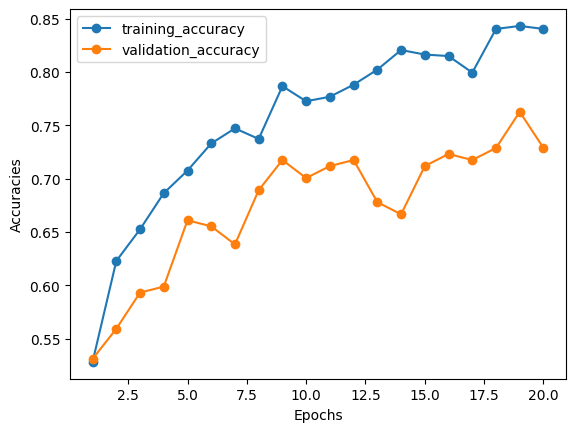

In [68]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1 , EPOCHS +1)

plt.plot(epochs,training_accuracy,label = "training_accuracy",marker = "o")
plt.plot(epochs,validation_accuracy,label = "validation_accuracy",marker = "o")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()

In [ ]:
from keras.callbacks import EarlyStopping

base_model_res.trainable = True

for layer in base_model_res.layers[:-30]:
    layer.trainable = False

res_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

res_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)


In [74]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = res_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                   precision    recall  f1-score   support

        Bird-drop       0.80      0.73      0.77        45
            Clean       0.67      0.59      0.62        34
            Dusty       0.70      0.81      0.75        43
Electrical-damage       0.52      0.75      0.62        16
  Physical-Damage       1.00      0.74      0.85        19
     Snow-Covered       0.95      0.90      0.92        20

         accuracy                           0.75       177
        macro avg       0.77      0.75      0.76       177
     weighted avg       0.76      0.75      0.75       177



### Hyperparameter Optimization (HPO) - ResNet50 with Randomized Search

In [ ]:
import numpy as np
from sklearn.utils import class_weight

# 1. Extract labels from training_data object
# training_data is the Raw dataset before mapping/caching
y_train = np.concatenate([y for x, y in training_data], axis=0)

# 2. Calculate weights
# 'balanced' mode automatically calculates weights inversely proportional to class frequencies
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 3. Create a dictionary for Keras
class_weight_dict = dict(enumerate(weights))

print("Calculated Class Weights:", class_weight_dict)
for i, weight in class_weight_dict.items():
    print(f"Class {training_data.class_names[i]}: {weight:.2f}")

Calculated Class Weights: {0: np.float64(0.7283950617283951), 1: np.float64(0.7421383647798742), 2: np.float64(0.8027210884353742), 3: np.float64(1.3563218390804597), 4: np.float64(2.36), 5: np.float64(1.145631067961165)}
Class Bird-drop: 0.73
Class Clean: 0.74
Class Dusty: 0.80
Class Electrical-damage: 1.36
Class Physical-Damage: 2.36
Class Snow-Covered: 1.15


In [ ]:
import keras_tuner as kt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input

def build_resnet_hypermodel(hp):
    # Base model: ResNet50 (Weights are frozen initially)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False 

    model = keras.Sequential([
        # Data Augmentation (Using existing layers)
        keras.Sequential([
            keras.layers.RandomFlip("horizontal"),
            keras.layers.RandomRotation(0.05),
            keras.layers.RandomZoom(0.05),
        ]),
        keras.layers.Lambda(preprocess_input),
        base_model,
        keras.layers.GlobalAveragePooling2D(),
        
        # Hyperparameter: Number of units in the first Dense layer
        keras.layers.Dense(
            units=hp.Int('dense_units', min_value=128, max_value=512, step=128),
            activation='relu'
        ),
        
        # Hyperparameter: Dropout rate
        keras.layers.Dropout(
            rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
        ),
        
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    # Hyperparameter: Learning rate
    lr = hp.Float('learning_rate', min_value=1e-5, max_value=3e-4, sampling='log')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [42]:
# Initialize the Tuner
tuner = kt.RandomSearch(
    build_resnet_hypermodel,
    objective='val_accuracy',
    max_trials=10, # Number of different combinations to try
    executions_per_trial=1,
    directory='solar_defect_tuning',
    project_name='resnet50_random_search',
    seed=42
)

# Run the search
tuner.search(
    train_dataset, 
    validation_data=val_dataset, 
    class_weight = class_weight_dict,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)]
)

# Get the best hyperparameters and model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Dense Units:", best_hps.get('dense_units'))
print("Best Dropout:", best_hps.get('dropout'))
print("Best Learning Rate:", best_hps.get('learning_rate'))

best_model = tuner.get_best_models()[0]

Trial 10 Complete [00h 03m 25s]
val_accuracy: 0.7118644118309021

Best val_accuracy So Far: 0.8192090392112732
Total elapsed time: 00h 38m 11s
Best Dense Units: 512
Best Dropout: 0.2
Best Learning Rate: 0.00026716512320126124


c:\Users\Paras\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [45]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = best_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                   precision    recall  f1-score   support

        Bird-drop       0.75      0.98      0.85        45
            Clean       0.81      0.85      0.83        34
            Dusty       0.83      0.56      0.67        43
Electrical-damage       0.92      0.75      0.83        16
  Physical-Damage       0.90      0.95      0.92        19
     Snow-Covered       0.90      0.90      0.90        20

         accuracy                           0.82       177
        macro avg       0.85      0.83      0.83       177
     weighted avg       0.83      0.82      0.81       177



[[44  0  0  0  1  0]
 [ 1 29  4  0  0  0]
 [10  7 24  0  1  1]
 [ 3  0  0 12  0  1]
 [ 0  0  0  1 18  0]
 [ 1  0  1  0  0 18]]


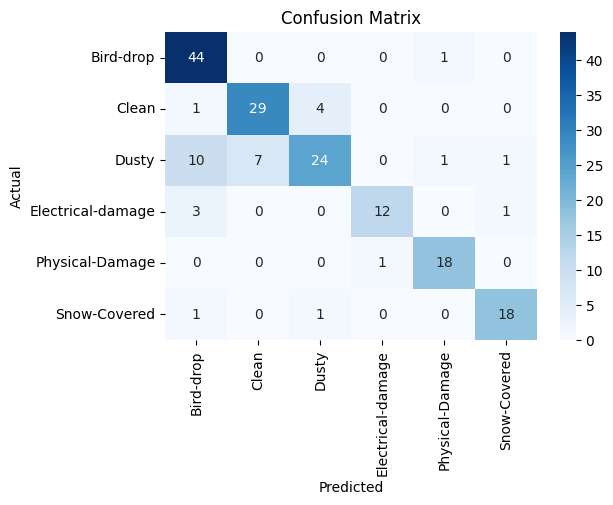

In [47]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
